# LoVoCCS 2D maps: Correlations between X-ray brightness and weak-lensing maps 

<span style="color:red">This section of the project investigates ...</span>

## Main takeaways 

In summary:

* We....

## Import Statements

In [28]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from matplotlib import pyplot as plt
import os
from astropy.units import Quantity
from astropy.visualization import LinearStretch, ImageNormalize, LogStretch, MinMaxInterval, SqrtStretch, AsinhStretch
from astropy.wcs import WCS
from astropy.io import fits
from shutil import rmtree
from fitsio import read
import umap
from sklearn.preprocessing import StandardScaler

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '../')
from common import lovoccs_cosmo, haversine

import xga
# This just sets the number of cores this analysis is allowed to use
xga.NUM_CORES = 10
from xga import CENSUS
# This is a bodge that will only work because xga_output in notebooks has already been defined, XGA
#  will be made to handle this more gracefully at some point
temp_dir = xga.OUTPUT
actual_dir = temp_dir.split('notebooks/')[0]+'notebooks/xga_output/'
xga.OUTPUT = actual_dir
xga.utils.OUTPUT = actual_dir
# As currently XGA will setup an xga_output directory in our current directory, I remove it to keep it all clean
if os.path.exists('xga_output'):
    rmtree('xga_output')
from xga.samples import ClusterSample
from xga.products import Image, ExpMap, RateMap
from xga.imagetools.misc import pix_deg_scale

%matplotlib inline

## Useful values

Here we set up any values that are useful to several parts of the analysis in this notebook, and that we might wish to change in the future:

In [2]:
#

## Useful functions

Here we set up any functions used in this notebook:

In [3]:
def generate_wcs_matched_xmm_prod(src, lo_en, hi_en, wl_map):
    """
    This function replicates how XGA generates XMM images and exposure maps, and then how it combines them - this is 
    necessary because the stable version of XGA does not yet support generating images/exposure maps with custom binning.
    """
    def prep_cmd_inputs(evt):
        oi = evt.obs_id
        inst = evt.instrument
        
        with fits.open(evt.path) as fitso:
            xmm_det_deg_scale = fitso[0].header['REFYCDLT']
            
        xmm_binning = int(round(wl_map_pix_deg_scale / xmm_det_deg_scale, 0))

        if "pn" in inst:
            add_expr = "'#XMMEA_EP' && (PATTERN <= 4) && (FLAG .eq. 0)"
        else:
            add_expr = "'#XMMEA_EM' && (PATTERN <= 12) && (FLAG .eq. 0)"
            
        expr = " && ".join([e for e in ["expression='(PI in [{l}:{u}])".format(l=lo_chan, u=hi_chan), add_expr] if e != ""]) + "'"

        return oi, inst, xmm_binning, xmm_det_deg_scale, expr

    # The directory setup
    out_dir = os.path.join(xmm_rebinned_fits_path, src.name)
    os.makedirs(out_dir, exist_ok=True)
    
    wl_map_pix_deg_scale = wl_map.header['PC2_2']

    # Center to use for new images
    cent_coord = wl_map.coord_conv(Quantity([wl_map.shape[1]/2, wl_map.shape[0]/2], 'pix'), 'deg')
    1    # Need the CCF file for anything related to exposure maps, though not for images
    ccf_pth = "../xga_output/{oi}/ccf.cif"
    # Also attitude file
    att_pth = "../../../X-LoVoCCS-Data/data/archives/LoVoCCS/processed_data/xmm_pointed/{oi}/P{oi}OBX000ATTTSR0000.FIT"

    # In XMM detector coordinates, the lower and upper boundaries of the WL-WCS-matched images we're trying to make
    xmm_detcoord_bounds = [3649-263, 48885+263]

    add_expr = ""
    # The energy selection expression
    lo_chan = lo_en.to('eV').value.astype(int)
    hi_chan = hi_en.to('eV').value.astype(int)
        
    im_cmd = ("evselect table={e} imageset={i} xcolumn=X ycolumn=Y ximagebinsize={bs} "
              "yimagebinsize={bs} squarepixels=yes raimagecenter={ra_cen} decimagecenter={dec_cen} " 
              "ximagemin={l} ximagemax={u} withxranges=yes yimagemin={l} "
              "yimagemax={u} withyranges=yes {ex}")
    ex_cmd = ("export SAS_CCF={ccf}; eexpmap eventset={e} imageset={im} expimageset={eim} withdetcoords=no withvignetting=yes "
              "attitudeset={att} pimin={l} pimax={u}")
    mosaic_cmd = ("emosaic imagesets='{ims}' mosaicedset={mim}")

    #
    rel_census = CENSUS[CENSUS['ObsID'].isin(src.obs_ids)]
    rel_dists = haversine(src.ra_dec[0].value, src.ra_dec[1].value, rel_census['RA_PNT'].values, rel_census['DEC_PNT'].values)
    start_oi = rel_census['ObsID'].values[np.argmin(rel_dists)]

    start_evts = src.get_products('events', obs_id=start_oi)[0]
    # This is not my most elegant work, but never mind
    cur_oi, cur_inst, cur_binning, cur_xmm_det_scale, cur_expr = prep_cmd_inputs(start_evts)
    
    start_im_pth = os.path.join(out_dir, 'start_im-{l}_{u}keV.fits'.format(l=lo_en.value, u=hi_en.value))
    cur_im_cmd = im_cmd.format(e=start_evts.path, i=start_im_pth, bs=cur_binning, 
                               ra_cen=round(cent_coord[0].value, 12), dec_cen=round(cent_coord[1].value, 12),
                               l=xmm_detcoord_bounds[0], u=xmm_detcoord_bounds[1], ex=cur_expr)
    start_ex_pth = os.path.join(out_dir, 'start_ex-{l}_{u}keV.fits'.format(l=lo_en.value, u=hi_en.value))
    cur_ex_cmd = ex_cmd.format(ccf=ccf_pth.format(oi=cur_oi), e=start_evts.path, im=start_im_pth, 
                               eim=start_ex_pth, att=att_pth.format(oi=cur_oi), l=lo_chan, u=hi_chan)

    final_cmds = [cur_im_cmd, cur_ex_cmd]
    final_ims = [start_im_pth]
    final_exs = [start_ex_pth]
    
    oi_cents = {}
    for evt_list in src.get_products('events'):
        if (evt_list.obs_id == start_evts.obs_id) and (evt_list.instrument == start_evts.instrument):
            continue

        cur_oi, cur_inst, cur_binning, cur_xmm_det_scale, cur_expr = prep_cmd_inputs(evt_list)
        
        if cur_oi == start_oi:
            rel_cent = cent_coord
        elif cur_oi in oi_cents:
            rel_cent = oi_cents[cur_oi]
        else:
            rel_rel_census = rel_census[rel_census['ObsID'] == cur_oi]
            cur_oi_cent = Quantity(rel_rel_census[['RA_PNT', 'DEC_PNT']].values[0], 'deg')
            delta_coord = cur_oi_cent - cent_coord

            # An XMM detecter coordinate offset now
            delta_coord_det = (delta_coord.value / cur_xmm_det_scale)
            # Now we divide by our chosen binning, so that we assess how far away they are from one another 
            #  in terms of our detector coordinate binning
            delta_coord_det_binned = delta_coord_det / cur_binning
            # Now we'll use this to see how many detector-coord binnings (e.g. pixels of our final images) we 
            #  should offset the central coordinate of this observation from the original central coord
            off_signs = np.sign(delta_coord_det_binned)
            off_int = np.ceil(np.abs(delta_coord_det_binned))
            off_int = (off_int*off_signs).astype(int)

            rel_cent = cent_coord + Quantity(off_int*cur_binning*cur_xmm_det_scale, 'deg')
            oi_cents[cur_oi] = rel_cent

        # -{l}_{u}keV.fits'.format(l=lo_en.value, u=hi_en.value)
        cur_im_pth = os.path.join(out_dir, '{oi}-{i}-{l}_{u}keV-image.fits'.format(oi=cur_oi, i=cur_inst, 
                                                                                   l=lo_en.value, u=hi_en.value))
        cur_im_cmd = im_cmd.format(e=evt_list.path, i=cur_im_pth, bs=cur_binning, 
                                   ra_cen=round(rel_cent[0].value, 12), dec_cen=round(rel_cent[1].value, 12),
                                   l=xmm_detcoord_bounds[0], u=xmm_detcoord_bounds[1], ex=cur_expr)
        final_cmds.append(cur_im_cmd)
        final_ims.append(cur_im_pth)
        
        cur_ex_pth = os.path.join(out_dir, '{oi}-{i}-{l}_{u}keV-expmap.fits'.format(oi=cur_oi, i=cur_inst, 
                                                                                    l=lo_en.value, u=hi_en.value))
        cur_ex_cmd = ex_cmd.format(ccf=ccf_pth.format(oi=cur_oi), e=evt_list.path, im=cur_im_pth, 
                                   eim=cur_ex_pth, att=att_pth.format(oi=cur_oi), l=lo_chan, u=hi_chan)
        final_cmds.append(cur_ex_cmd)
        final_exs.append(cur_ex_pth)
    
    cur_mos_im = mosaic_cmd.format(ims=" ".join(final_ims), 
                                   mim=os.path.join(out_dir, "combined_image-{l}_{u}keV.fits".format(l=lo_en.value, u=hi_en.value)))
    final_cmds.append(cur_mos_im)
    
    cur_mos_ex = mosaic_cmd.format(ims=" ".join(final_exs), 
                                   mim=os.path.join(out_dir, "combined_expmap-{l}_{u}keV.fits".format(l=lo_en.value, u=hi_en.value)))
    final_cmds.append(cur_mos_ex)
    
    final_cmd = ";".join(final_cmds)

    return final_cmd

## Output paths

Paths to save comparison figures and any output results files - defined here to avoid repetition and make the code easier to read: 

In [4]:
# This directory will likely not be included in the GitHub repo, due to file sizes
xmm_rebinned_fits_path = "../../outputs/cluster_visualisations/xmm_wcs-matched_wlmap_fits/"
os.makedirs(xmm_rebinned_fits_path, exist_ok=True)

## Loading data files

Important considerations for this dataset:

* ...

### X-LoVoCCS-I base sample

In [5]:
xlovoccs_base = pd.read_csv("../../sample_files/X-LoVoCCSI.csv")
xlovoccs_base.insert(0, 'name', xlovoccs_base['LoVoCCSID'].apply(lambda x: "LoVoCCS-" + str(x)))
xlovoccs_base.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
0,LoVoCCS-1,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44
1,LoVoCCS-2,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44
2,LoVoCCS-4A,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44
3,LoVoCCS-4B,4B,4,A85South,10.451487,-9.460007,0.0555,1.2103,10.45875,-9.301944,10.451487,-9.460007,5.100085e+44
4,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44
5,LoVoCCS-7,7,7,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44


<span style="color:red">Maybe something more formal</span>

In [6]:
xlovoccs_samp = xlovoccs_base

## Loading LoVoCCS 2D weak-lensing SNR maps

In [7]:
# wl_snr_map = Image("../../noupload_LoVoCCS-26_M_ap_SNR_b100_Rs13000.fits", '', '', '', '', '', Quantity(0.0, 'keV'), Quantity(0.0, 'keV'))
# wl_snr_map = Image("../../noupload_LoVoCCS-58_M_ap_SNR_b100_Rs3000.fits", '', '', '', '', '', Quantity(0.0, 'keV'), Quantity(0.0, 'keV'))
# wl_snr_map = Image("../../noupload_LoVoCCS-2-14_M_ap_SNR_b100_Rs7000.fits", '', '', '', '', '', Quantity(0.0, 'keV'), Quantity(0.0, 'keV'))
wl_snr_map = Image("../../sample_files/aperture_mass_maps/LoVoCCS-11_M_ap_SNR_b100_Rs14000_maxEsnr.fits", '', '', '', '', '', 
                   Quantity(0.0, 'keV'), Quantity(0.0, 'keV'))

wl_snr_map_hdr = wl_snr_map.header

wl_snr_map_w = WCS(naxis=2)
key = ''

wl_snr_map_w.wcs.crpix = [wl_snr_map_hdr["CRPIX1{}".format(key)], wl_snr_map_hdr["CRPIX2{}".format(key)]]
wl_snr_map_w.wcs.cdelt = [wl_snr_map_hdr["PC1_1{}".format(key)], wl_snr_map_hdr["PC2_2{}".format(key)]]
wl_snr_map_w.wcs.crval = [wl_snr_map_hdr["CRVAL1{}".format(key)], wl_snr_map_hdr["CRVAL2{}".format(key)]]
wl_snr_map_w.wcs.ctype = [wl_snr_map_hdr["CTYPE1{}".format(key)], wl_snr_map_hdr["CTYPE2{}".format(key)]]

wl_snr_map._wcs_radec = wl_snr_map_w

wl_snr_map._data = read(wl_snr_map.path).astype("float64")
wl_snr_map._shape = wl_snr_map.data.shape

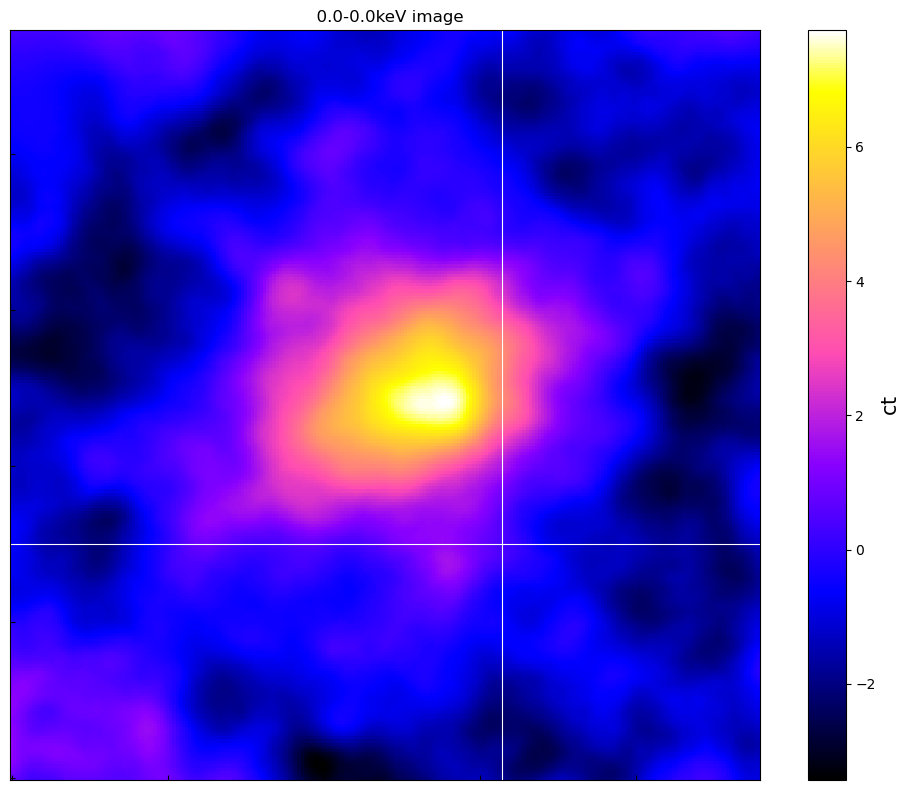

In [175]:
wl_snr_map.view(Quantity([157, 75], 'pix'), stretch=LinearStretch())

## Defining an XGA ClusterSample

In [9]:
xlovoccs_samp = xlovoccs_samp[~xlovoccs_samp['LoVoCCSID'].isin(['41C', '33'])]

**<span style="color:red">AN INITIAL BODGE</span>**

In [10]:
# 'LoVoCCS-2', 'LoVoCCS-14'
xlovoccs_samp = xlovoccs_samp[xlovoccs_samp['name'].isin(['LoVoCCS-11', 'LoVoCCS-26', 'LoVoCCS-58'])]

new_ind = xlovoccs_samp.shape[0]
xlovoccs_samp.loc[new_ind, 'name'] = 'LoVoCCS-2-14'
xlovoccs_samp.loc[new_ind, 'start_ra'] = 44.6293904
xlovoccs_samp.loc[new_ind, 'start_dec'] = 13.3709171
xlovoccs_samp.loc[new_ind, 'MCXC_Redshift'] = 0.0739
xlovoccs_samp.loc[new_ind, 'MCXC_R500'] = 1.

**<span style="color:red">OBVIOUSLY REMOVE</span>**

In [11]:
xlovoccs_samp

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
8,LoVoCCS-11,11,11.0,A754,137.280000,-9.670000,0.0542,1.1439,137.280000,-9.670000,NaN,NaN,3.849660e+44
17,LoVoCCS-26,26,26.0,A2426,333.635833,-10.371667,0.0980,1.0442,333.635833,-10.371667,NaN,NaN,2.770068e+44
39,LoVoCCS-58,58,58.0,A2351,323.568242,-13.438889,0.0897,0.9604,323.570000,-13.480000,323.568242,-13.438889,1.793951e+44
3,LoVoCCS-2-14,NaN,NaN,NaN,44.629390,13.370917,0.0739,1.0000,NaN,NaN,NaN,NaN,NaN


In [12]:
srcs = ClusterSample(xlovoccs_samp['start_ra'].values, xlovoccs_samp['start_dec'].values, xlovoccs_samp['MCXC_Redshift'].values, 
                     xlovoccs_samp['name'].values, r500=Quantity(xlovoccs_samp['MCXC_R500'].values, 'Mpc'), use_peak=False, 
                     clean_obs=False, cosmology=lovoccs_cosmo)
srcs.info()

Setting up Galaxy Clusters: 100%|██████████| 4/4 [00:14<00:00,  3.72s/it]


-----------------------------------------------------
Number of Sources - 4
Redshift Information - True
Sources with ≥1 detection - 3 [75%]
-----------------------------------------------------




/mnt/home/turne540/software/anaconda3/envs/xga_release/lib/python3.12/site-packages/xga/samples/extended.py:308: UserWarning: Non-fatal warnings occurred during the declaration of some sources, to access them please use the suppressed_warnings property of this sample.
  self._check_source_warnings()


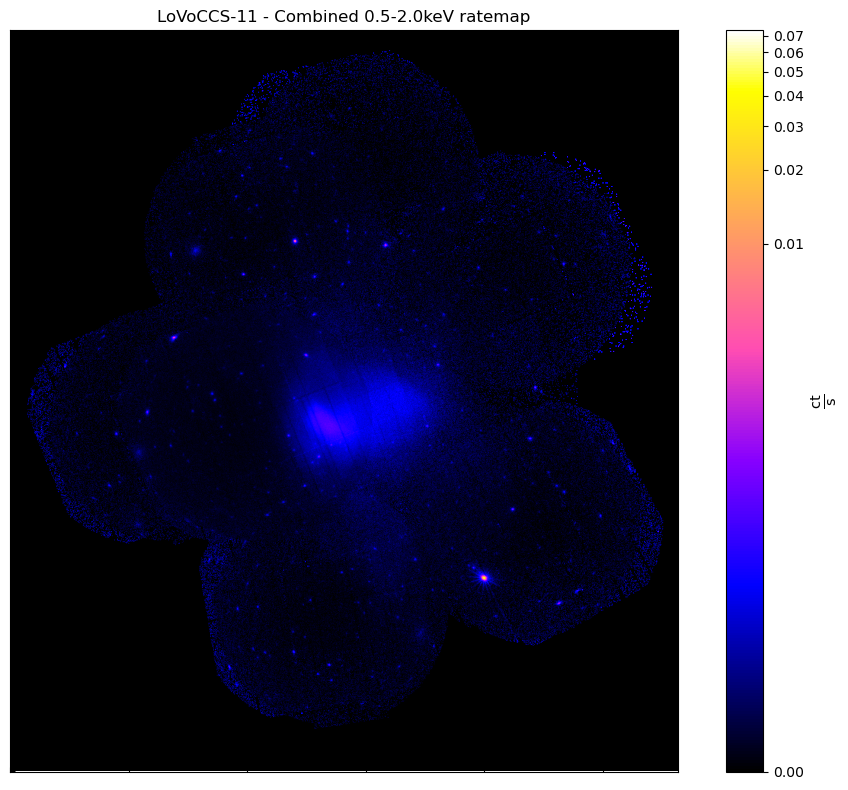

In [13]:
srcs[0].get_combined_ratemaps().view()

## Generating XMM count-rate maps matching WL map WCS

In [16]:
test_cmd = generate_wcs_matched_xmm_prod(srcs[0], Quantity(0.5, 'keV'), Quantity(2.0, 'keV'), wl_snr_map)
# test_cmd = generate_wcs_matched_xmm_prod(srcs[2], Quantity(0.5, 'keV'), Quantity(8.0, 'keV'), wl_snr_map)
# test_cmd = generate_wcs_matched_xmm_prod(srcs[2], Quantity(2, 'keV'), Quantity(5.0, 'keV'), wl_snr_map)

In [17]:
test_cmd

"evselect table=/mnt/ufs18/rs-033/mc2/LoVoCCS/X-LoVoCCS-Data/data/archives/LoVoCCS/processed_data/xmm_pointed/0136740101/events/obsid0136740101-instPN-subexpALL-en-finalevents.fits imageset=../../outputs/cluster_visualisations/xmm_wcs-matched_wlmap_fits/LoVoCCS-11/start_im-0.5_2.0keV.fits xcolumn=X ycolumn=Y ximagebinsize=526 yimagebinsize=526 squarepixels=yes raimagecenter=137.281177002213 decimagecenter=-9.663742038384 ximagemin=3386 ximagemax=49148 withxranges=yes yimagemin=3386 yimagemax=49148 withyranges=yes expression='(PI in [500:2000]) && '#XMMEA_EP' && (PATTERN <= 4) && (FLAG .eq. 0)';export SAS_CCF=../xga_output/0136740101/ccf.cif; eexpmap eventset=/mnt/ufs18/rs-033/mc2/LoVoCCS/X-LoVoCCS-Data/data/archives/LoVoCCS/processed_data/xmm_pointed/0136740101/events/obsid0136740101-instPN-subexpALL-en-finalevents.fits imageset=../../outputs/cluster_visualisations/xmm_wcs-matched_wlmap_fits/LoVoCCS-11/start_im-0.5_2.0keV.fits expimageset=../../outputs/cluster_visualisations/xmm_wcs-ma

In [19]:
cur_wcs_matched_im = Image("../../outputs/cluster_visualisations/xmm_wcs-matched_wlmap_fits/LoVoCCS-11/combined_image-0.5_2.0keV.fits", 
                           "combined", "combined", '', '', '', Quantity(0.5, 'keV'), Quantity(2, 'keV'))
cur_wcs_matched_ex = ExpMap("../../outputs/cluster_visualisations/xmm_wcs-matched_wlmap_fits/LoVoCCS-11/combined_expmap-0.5_2.0keV.fits", 
                            "combined", "combined", '', '', '', Quantity(0.5, 'keV'), Quantity(2, 'keV'))

In [20]:
pad_xray_im = np.zeros(wl_snr_map.shape)
pad_xray_ex = np.zeros(wl_snr_map.shape)

In [21]:
wl_snr_map.radec_wcs.all_pix2world(*[wl_snr_map.shape[1]/2, wl_snr_map.shape[0]/2], 1)

[array(137.28858779), array(-9.6710476)]

In [22]:
# Numpy array pixel coordinates
wl_zero = np.array(wl_snr_map.radec_wcs.all_pix2world(*[0, 0], 0))
# The numpy-convention (i.e. starts at zero) coordinates
padding_offset = np.array(cur_wcs_matched_im.radec_wcs.all_world2pix(*wl_zero, 0)).round().astype(int)*-1
np_padding_offset = np.flip(padding_offset)
np_padding_offset

array([20, 23])

**<span style="color:red">THIS BIT WOULD PROBABLY FALL OVER IN THE CASE OF X-RAY DATA GOING OVER THE LEFT/BOTTOM EDGES OF THE WL MAP</span>**

In [23]:
wl_offset_lims = np.array(wl_snr_map.shape)-np_padding_offset
wl_offset_lims

array([220, 217])

In [24]:
np.array(cur_wcs_matched_im.shape)

array([212, 191])

In [26]:
pad_xray_im[np_padding_offset[0]:np_padding_offset[0]+cur_wcs_matched_im.shape[0], 
            np_padding_offset[1]:np_padding_offset[1]+cur_wcs_matched_im.shape[1]] = cur_wcs_matched_im.data

pad_xray_ex[np_padding_offset[0]:np_padding_offset[0]+cur_wcs_matched_im.shape[0], 
            np_padding_offset[1]:np_padding_offset[1]+cur_wcs_matched_im.shape[1]] = cur_wcs_matched_ex.data

/tmp/ipykernel_4100190/1826235255.py:3: RuntimeWarning: invalid value encountered in divide
  norm = ImageNormalize((pad_xray_im/pad_xray_ex), MinMaxInterval(), stretch=LogStretch())
/tmp/ipykernel_4100190/1826235255.py:5: RuntimeWarning: invalid value encountered in divide
  plt.imshow((pad_xray_im/pad_xray_ex), 'gnuplot2', norm, origin='lower')


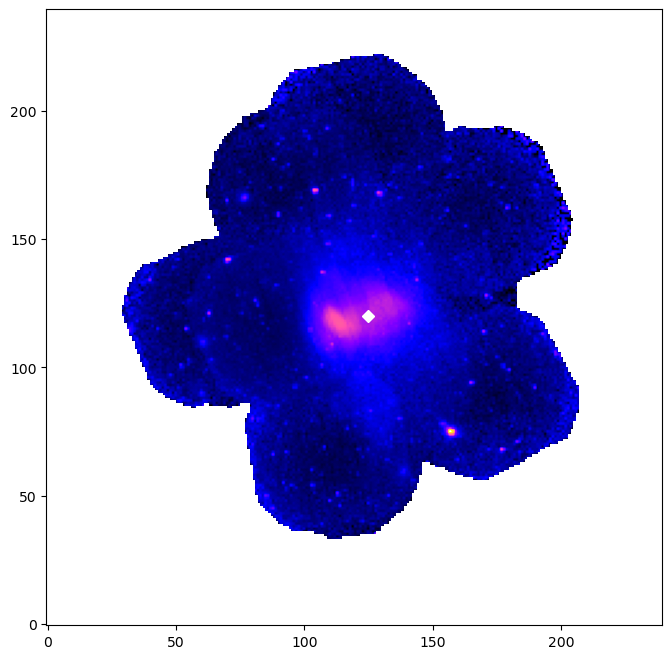

In [33]:
plt.figure(figsize=(8, 8))

norm = ImageNormalize((pad_xray_im/pad_xray_ex), MinMaxInterval(), stretch=LogStretch())
# plt.imshow((pad_xray_im/pad_xray_ex)[115:115+28, 125:125+28], 'gnuplot2', norm, origin='lower')
plt.imshow((pad_xray_im/pad_xray_ex), 'gnuplot2', norm, origin='lower')

plt.plot(125, 120, 'D', color='white')

plt.show()

In [29]:
all_the_inds = np.indices(wl_snr_map.data.shape)
all_the_inds.shape

(2, 240, 240)

In [34]:
arr_y, arr_x = np.ogrid[:wl_snr_map.data.shape[0], :wl_snr_map.data.shape[1]]

rec_x = arr_x - 125
rec_y = arr_y - 120
seps = np.sqrt(rec_x**2 + rec_y**2)

/tmp/ipykernel_4100190/3025114943.py:3: RuntimeWarning: invalid value encountered in divide
  plt.scatter(wl_snr_map.data.flatten(), np.sqrt((pad_xray_im/pad_xray_ex).flatten()), marker='.', c=seps,


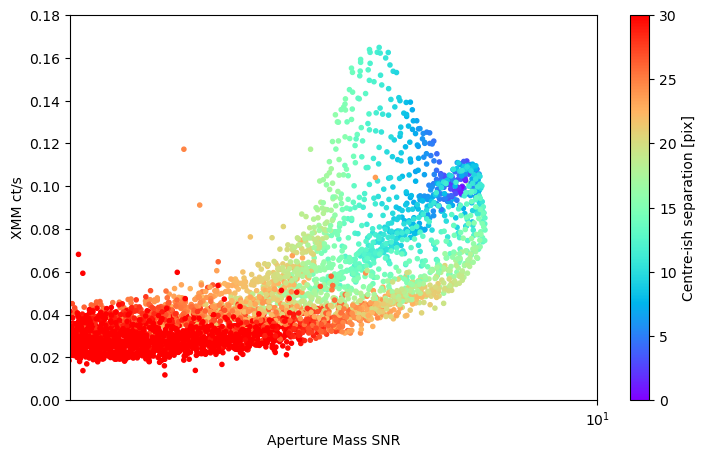

In [67]:
plt.figure(figsize=(8.5, 5))

plt.scatter(wl_snr_map.data.flatten(), np.sqrt((pad_xray_im/pad_xray_ex).flatten()), marker='.', c=seps, 
            cmap='rainbow', norm='linear', vmin=0, vmax=30)

# wl_restrict = wl_snr_map.data[115:115+28, 125:125+28].flatten()
# x_restrict = (pad_xray_im/pad_xray_ex)[115:115+28, 125:125+28].flatten()

# plt.plot(wl_restrict, x_restrict, 'D', color='black', alpha=0.7)

plt.ylabel('XMM ct/s')
plt.xlabel('Aperture Mass SNR')

plt.xscale('symlog')
# plt.yscale('log')

plt.xlim(3, 10)
# plt.ylim(0.0025)
# plt.ylim(0.0, 0.03)
plt.ylim(0.0, 0.18)

plt.colorbar(label='Centre-ish separation [pix]')
plt.show()

/tmp/ipykernel_4100190/2096717630.py:3: RuntimeWarning: invalid value encountered in divide
  plt.scatter(wl_snr_map.data.flatten(), (pad_xray_im/pad_xray_ex).flatten(), marker='.', c=seps,


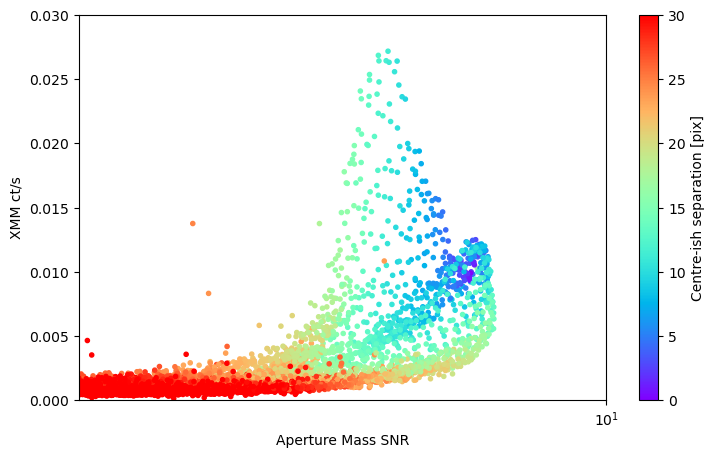

In [82]:
plt.figure(figsize=(8.5, 5))

plt.scatter(wl_snr_map.data.flatten(), (pad_xray_im/pad_xray_ex).flatten(), marker='.', c=seps, 
            cmap='rainbow', norm='linear', vmin=0, vmax=30)

# wl_restrict = wl_snr_map.data[115:115+28, 125:125+28].flatten()
# x_restrict = (pad_xray_im/pad_xray_ex)[115:115+28, 125:125+28].flatten()

# plt.plot(wl_restrict, x_restrict, 'D', color='black', alpha=0.7)

plt.ylabel('XMM ct/s')
plt.xlabel('Aperture Mass SNR')

plt.xscale('symlog')
# plt.yscale('log')

plt.xlim(3, 10)
# plt.ylim(0.0025)
plt.ylim(0.0, 0.03)
# plt.ylim(0.0, 0.18)

plt.colorbar(label='Centre-ish separation [pix]')
plt.show()

## Dimensionality reduction

In [177]:
all_data = np.vstack([all_the_inds[0, :, :].flatten(), all_the_inds[1, :, :].flatten(), wl_snr_map.data.flatten(), 
                      (pad_xray_im/pad_xray_ex).flatten()]).T
ind_arr = np.arange(0, len(all_data))
xy_data = np.vstack([all_the_inds[0, :, :].flatten(), all_the_inds[1, :, :].flatten()]).T

# good_data_msk = (~np.isnan(all_data)).all(axis=1)*(all_data[:, -1] > 0.0025)
# good_data = all_data[good_data_msk]
# good_xy_arr = xy_data[good_data_msk]

all_data = np.vstack([wl_snr_map.data.flatten(), (pad_xray_im/pad_xray_ex).flatten()]).T
xy_data = np.vstack([all_the_inds[0, :, :].flatten(), all_the_inds[1, :, :].flatten()]).T
good_data_msk = (~np.isnan(all_data)).all(axis=1)*(all_data[:, -1] > 0.0025)
# good_data_msk = (~np.isnan(all_data)).all(axis=1)*(all_data[:, -1] > 0.0015)
good_data = all_data[good_data_msk]
good_ind_arr = ind_arr[good_data_msk]

scaled_data = StandardScaler().fit_transform(all_data[good_data_msk])

/tmp/ipykernel_4100190/3591491215.py:2: RuntimeWarning: invalid value encountered in divide
  (pad_xray_im/pad_xray_ex).flatten()]).T
/tmp/ipykernel_4100190/3591491215.py:10: RuntimeWarning: invalid value encountered in divide
  all_data = np.vstack([wl_snr_map.data.flatten(), (pad_xray_im/pad_xray_ex).flatten()]).T


In [178]:
umap_dim_red = umap.UMAP(random_state=907)
umap_reduced = umap_dim_red.fit_transform(scaled_data)

/mnt/home/turne540/software/anaconda3/envs/xga_release/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


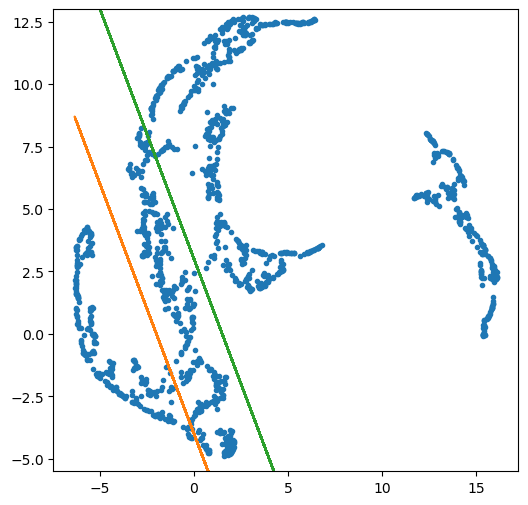

In [211]:
plt.figure(figsize=(6, 6))

new_line_boi = lambda x: -2*x  -4

oth_new_line_boi = lambda x: -2*x+3

plt.plot(umap_reduced[:, 0], umap_reduced[:, 1], '.')
plt.plot(umap_reduced[:, 0], new_line_boi(umap_reduced[:, 0]))
plt.plot(umap_reduced[:, 0], oth_new_line_boi(umap_reduced[:, 0]))

plt.ylim(-5.5, 13)
plt.show()

/tmp/ipykernel_4100190/3352019494.py:3: RuntimeWarning: invalid value encountered in divide
  norm = ImageNormalize((pad_xray_im/pad_xray_ex), MinMaxInterval(), stretch=LogStretch())
/tmp/ipykernel_4100190/3352019494.py:5: RuntimeWarning: invalid value encountered in divide
  plt.imshow((pad_xray_im/pad_xray_ex), 'gnuplot2', norm, origin='lower')


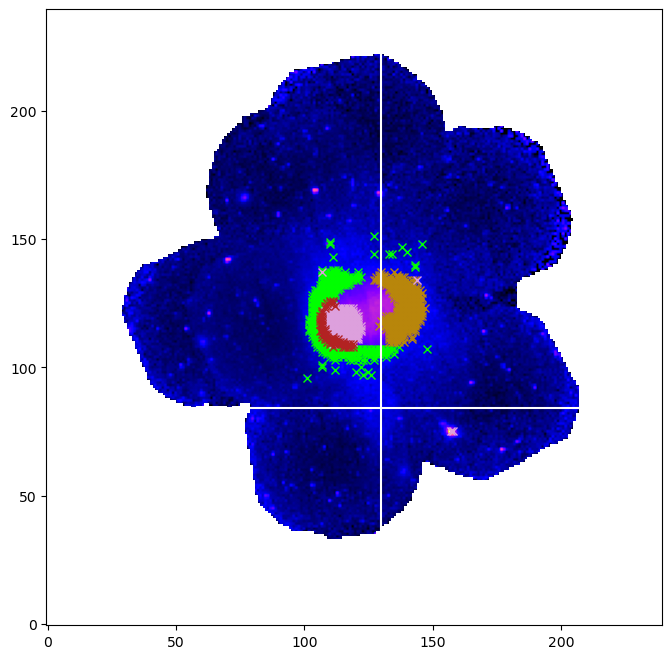

In [207]:
plt.figure(figsize=(8, 8))

norm = ImageNormalize((pad_xray_im/pad_xray_ex), MinMaxInterval(), stretch=LogStretch())
# plt.imshow((pad_xray_im/pad_xray_ex)[115:115+28, 125:125+28], 'gnuplot2', norm, origin='lower')
plt.imshow((pad_xray_im/pad_xray_ex), 'gnuplot2', norm, origin='lower')

# chos_data = good_data[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] < -4.8)]
# chos_ind = good_ind_arr[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] < -4.8)]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='darkgoldenrod')

# chos_data = good_data[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > -4.8)]
# chos_ind = good_ind_arr[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > -4.8)]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='firebrick')

# chos_data = good_data[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > 5)]
# chos_ind = good_ind_arr[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > 5)]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='darkgoldenrod')

# chos_data = good_data[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > -4.8)]
# chos_ind = good_ind_arr[(umap_reduced[:, 0] < 10) & (umap_reduced[:, 1] > -4.8)]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='firebrick')

chos_data = good_data[umap_reduced[:, 1] > 8]
chos_ind = good_ind_arr[umap_reduced[:, 1] > 8]
plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='lime')

chos_data = good_data[umap_reduced[:, 1] < new_line_boi(umap_reduced[:, 0])]
chos_ind = good_ind_arr[umap_reduced[:, 1] < new_line_boi(umap_reduced[:, 0])]
plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='darkgoldenrod')

chos_data = good_data[(umap_reduced[:, 0] > 0) & (umap_reduced[:, 0] < 7) & (umap_reduced[:, 1] > 0) & (umap_reduced[:, 1] < 5)]
chos_ind = good_ind_arr[(umap_reduced[:, 0] > 0) & (umap_reduced[:, 0] < 7) & (umap_reduced[:, 1] > 0) & (umap_reduced[:, 1] < 5)]
plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='plum')

chos_data = good_data[(umap_reduced[:, 0] > 0) & (umap_reduced[:, 0] < 7) & (umap_reduced[:, 1] > 5) & (umap_reduced[:, 1] < 8)]
chos_ind = good_ind_arr[(umap_reduced[:, 0] > 0) & (umap_reduced[:, 0] < 7) & (umap_reduced[:, 1] > 5) & (umap_reduced[:, 1] < 8)]
plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='firebrick')

chos_data = good_data[(umap_reduced[:, 1] < oth_new_line_boi(umap_reduced[:, 0])) & 
                      (umap_reduced[:, 1] > new_line_boi(umap_reduced[:, 0]))]
chos_ind = good_ind_arr[(umap_reduced[:, 1] < oth_new_line_boi(umap_reduced[:, 0])) & 
                        (umap_reduced[:, 1] > new_line_boi(umap_reduced[:, 0]))]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='darkseagreen')

# chos_data = good_data[(umap_reduced[:, 0] > 7.5) & (umap_reduced[:, 1] < 1.5) & (umap_reduced[:, 1] > 0)]
# chos_ind = good_ind_arr[(umap_reduced[:, 0] > 7.5) & (umap_reduced[:, 1] < 1.5) & (umap_reduced[:, 1] > 0)]
# plt.plot(xy_data[chos_ind, 1], xy_data[chos_ind, 0], 'x', color='lime')

# plt.axvline(157, color='white')
# plt.axhline(75, color='white')

plt.axvline(130, color='white')
plt.axhline(84, color='white')

plt.show()

/tmp/ipykernel_4100190/3234494538.py:3: RuntimeWarning: invalid value encountered in divide
  plt.scatter(wl_snr_map.data.flatten(), np.sqrt(pad_xray_im/pad_xray_ex).flatten(), marker='.', c=seps,
/tmp/ipykernel_4100190/3234494538.py:9: RuntimeWarning: invalid value encountered in divide
  x_restrict = np.sqrt(pad_xray_im/pad_xray_ex).flatten()[chos_ind]


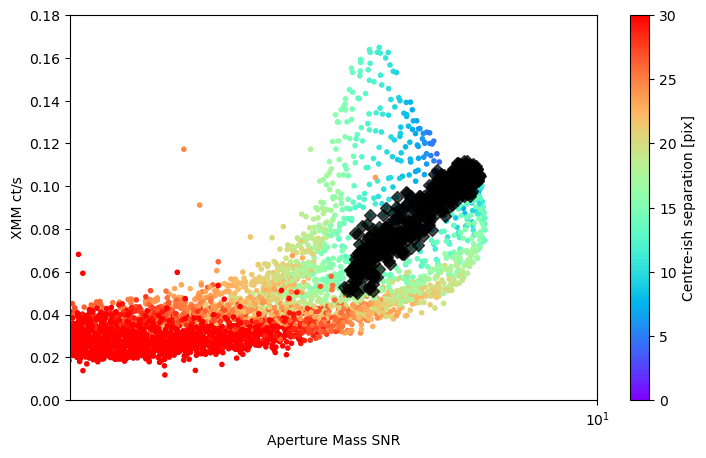

In [210]:
plt.figure(figsize=(8.5, 5))

plt.scatter(wl_snr_map.data.flatten(), np.sqrt(pad_xray_im/pad_xray_ex).flatten(), marker='.', c=seps, 
            cmap='rainbow', norm='linear', vmin=0, vmax=30)

# chos_ind = good_ind_arr[umap_reduced[:, 1] > 8]
# chos_ind = good_ind_arr[umap_reduced[:, 1] < new_line_boi(umap_reduced[:, 0])]
wl_restrict = wl_snr_map.data.flatten()[chos_ind]
x_restrict = np.sqrt(pad_xray_im/pad_xray_ex).flatten()[chos_ind]

plt.plot(wl_restrict, x_restrict, 'D', color='black', alpha=0.7)

plt.ylabel('XMM ct/s')
plt.xlabel('Aperture Mass SNR')

plt.xscale('symlog')
# plt.yscale('log')

plt.xlim(3, 10)
# plt.ylim(0.0025)
# plt.ylim(0.0, 0.03)
# plt.ylim(0.0, 0.005)
plt.ylim(0.0, 0.18)

plt.colorbar(label='Centre-ish separation [pix]')
plt.show()

In [ ]:
plt.figure(figsize=(8.5, 5))

plt.scatter(wl_snr_map.data.flatten(), (pad_xray_im/pad_xray_ex).flatten(), marker='.', c=seps, cmap='rainbow', norm='linear')

wl_restrict = wl_snr_map.data.flatten()[chos_ind]
x_restrict = (pad_xray_im/pad_xray_ex).flatten()[chos_ind]

plt.plot(wl_restrict, x_restrict, 'D', color='black', alpha=0.7)


plt.ylabel('XMM ct/s')
plt.xlabel('Aperture Mass SNR')

plt.xscale('symlog')
# plt.yscale('log')

plt.xlim(1, 7)
plt.ylim(0.0025)
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(8.5, 5))

plt.scatter(wl_snr_map.data.flatten(), (pad_xray_im/pad_xray_ex).flatten(), marker='.', c=seps, cmap='rainbow', norm='linear')

line_boi = lambda x: x*0.006 - 0.021

plt.plot(wl_snr_map.data.flatten(), line_boi(wl_snr_map.data.flatten()))

plt.ylabel('XMM ct/s')
plt.xlabel('Aperture Mass SNR')

# plt.xscale('symlog')
# plt.yscale('log')

plt.xlim(1, 7)
plt.ylim(0.0025)
plt.colorbar()
plt.show()

In [ ]:
lower_spike_inds = np.argwhere((pad_xray_im/pad_xray_ex).flatten() < line_boi(wl_snr_map.data.flatten())).flatten()

In [ ]:
all_data

In [ ]:
plt.figure(figsize=(8, 8))

norm = ImageNormalize((pad_xray_im/pad_xray_ex), MinMaxInterval(), stretch=LogStretch())
# plt.imshow((pad_xray_im/pad_xray_ex)[115:115+28, 125:125+28], 'gnuplot2', norm, origin='lower')
plt.imshow((pad_xray_im/pad_xray_ex), 'gnuplot2', norm, origin='lower')

plt.plot(all_data[lower_spike_inds, 1], all_data[lower_spike_inds, 0], 'x', color='darkgoldenrod')


plt.show()

Quick ratio

In [ ]:
plt.figure(figsize=(8, 8))

ratios = (pad_xray_im/pad_xray_ex) / wl_snr_map.data
norm = ImageNormalize(ratios, MinMaxInterval(), stretch=AsinhStretch())

plt.imshow(ratios, 'gnuplot2', norm, origin='lower')
plt.show()